### import libraries 

In [1]:
import shutil, os
import numpy as np
import pandas as pd
import math
from math import atan2
import random
import statistics
import csv
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib import rcParams, cycler
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter, LinearLocator, FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes,  zoomed_inset_axes
# from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
%matplotlib inline

import geopandas as gpd
import shapely
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiPolygon, box, mapping
from shapely.ops import nearest_points, unary_union #, cascaded_union
import warnings
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=RuntimeWarning, module="shapely")
#import shapely.speedups

import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio import Affine # or from affine import Affine
from rasterio.plot import plotting_extent
from glob import glob 

import osmnx as ox
import networkx as nx
ox.settings.log_console=True
ox.__version__


'2.0.6'

### read files (eez, eez_12nm, eez_24nm) and initialize parameters

In [2]:
def Param_Initialize():
    global eez, eez_12nm, eez_24nm, IFA, IFA_poly, simulation_type, init_fish, Beta, resource_threshold, low_end, natural_mortality  
    global move_fish, growth_prob, K, num_pirogue, catchability, time, time1, frac_coop, coop_effort, noncoop_effort
    global TOTAL_CATCH, TOTAL_FISH, CURRENT_CATCH, AVERAGE_EFFORT, num_days, month, closure_month
    
    # reading shapefiles
    eez  = gpd.read_file(os.path.join(os.getcwd(), 'eez/eez.shp')) # Exclusive Economic Zone (200 nautical miles)
    eez_12nm  = gpd.read_file(os.path.join(os.getcwd(), 'eez_12nm/eez_12nm.shp')) # 12 nautical miles zones (territorial seas)
    eez_24nm  = gpd.read_file(os.path.join(os.getcwd(), 'eez_24nm/eez_24nm.shp')) # 24 nautical miles zones (contiguous zones)
    
    ##reproject crs (to convert from sq. meters to sq. kilometers multiply by 1e-6)
    eez  = eez.to_crs(epsg=32630) 
    eez_12nm  = eez_12nm.to_crs(epsg=32630) 
    eez_24nm  = eez_24nm.to_crs(epsg=32630) 

    # remove inland waters from eez_12nm
    inland_water1=box(840e3, 640e3, 945e3, 680e3)
    inland_water2=box(480e3, 562.25e3, 520e3, 570e3)
    inland_waters = gpd.GeoDataFrame([inland_water1,inland_water2],geometry='geometry',columns=['geometry'], crs=eez_12nm.crs) 
    eez_12nm = gpd.overlay(eez_12nm, inland_waters, how='difference',keep_geom_type=True) # IFA = (territorial seas) + (contiguous zones) 

    # # inshore fishing area (IFA) 
    # IFA = gpd.overlay(eez_12nm, eez_24nm, how='union',keep_geom_type=True) # IFA = (territorial seas) + (contiguous zones) 
    # IFA_poly=unary_union([eez_12nm.at[0,'geometry'],eez_24nm.at[0,'geometry']]) # shpfile equivalent of IFA
    # alternative based on 12NM inshore exclusive zone (IEZ)
    IFA = eez_12nm  
    IFA_poly=eez_12nm.at[0,'geometry'] # shpfile equivalent of IFA

    ## parameters
    simulation_type = 'CENTRAL UPWELLING CLOSURE' # NO CLOSURE, TOTAL CLOSURE, CENTRAL UPWELLING CLOSURE
    closure_month = ['July'] # July, August, September (if NO CLOSURE, set to 'none')
    
    # fish characteristics
    K = 2600 # carrying capacity of fishing ground
    init_fish = int(K/2) # initial number of fish
    move_fish = 10309 # side length of square cell (meters/day)(diagonal gives the half-maximum-distance covered)
    growth_prob = 0.0019 #0.693 # maximum intrinsic growth rate
    natural_mortality = 0.00183 # natural mortality 
    
    # Fisher characteristics
    num_pirogue = 140 # number of pirogues 
    catchability = 0.5 # catchability of pirogues
    frac_coop = 1 # fraction of cooperators (1-frac_coop = frac_noncoop)
    coop_effort = 0.5 # effort of cooperators (fraction of fish to potentially harvest)
    noncoop_effort = 1 # effort of noncooperators (fraction of fish to potentially harvest)
    low_end = 0 # low end temperature ranging from  0 to 1 (default is 0)
    # resource_threshold = 14  # resource threshold (or K/number of cells = 2600/181 =14)
    # Beta = 0.3   # sensitivity for updated effort (0-1)
    
    time = 0 
    time1 = [time]
    month = 'July' # start month must always be July
    num_days = 91 # number of simulation days 
    
    TOTAL_CATCH = [0]
    CURRENT_CATCH =[0]
    TOTAL_FISH = [init_fish]
    AVERAGE_EFFORT = [coop_effort]
     
Param_Initialize() 


### setting square cell on fishing ground

In [3]:
def Regular_Cell():
    global cell, cells, cells_eez_12nm, cells_eez_24nm
    
    xmin, ymin, xmax, ymax = IFA_poly.bounds # get the bounds of IFA

    #cell size 
    cell_size = move_fish # side length of the square side 
    # create the cells in a loop
    polygons = []
    for x0 in np.arange(xmin, xmax, cell_size):
        for y0 in np.arange(ymin, ymax, cell_size):

            # bounds of polygon
            x1 = x0+cell_size 
            y1 = y0+cell_size

            polygons.append(box(x0, y0, x1, y1))
        
    # form geodataframe 
    cell = gpd.GeoDataFrame(polygons,geometry='geometry',columns=['geometry'],crs=IFA.crs) 
    cells = gpd.overlay(IFA, cell, how='intersection') # only cells within the IFA
    cells['area'] = cells.apply(lambda row: row['geometry'].area, axis=1)
    
    cells_eez_12nm = gpd.overlay(eez_12nm, cell, how='intersection') # only cells within the ees_12nm
    cells_eez_12nm['area'] = cells_eez_12nm.apply(lambda row: row['geometry'].area, axis=1)
    cells_eez_24nm = gpd.overlay(eez_24nm, cell, how='intersection') # only cells within the ees_24nm
    cells_eez_24nm['area'] = cells_eez_24nm.apply(lambda row: row['geometry'].area, axis=1)
    

Regular_Cell() 


## ecologically or biologically significant marine area (EBSA)

In [4]:
def Hotspots_upwelling():
    global upwelling_gdf_bound, cells_without_upwelling_gdf, normalised_upwelling_temp, scaled_upwelling_temp, low_end
    
    lat_min = 4.6
    lat_max = 5.4
    lon_min = -3.1
    lon_max = -1.7
    
    # Create a GeoDataFrame for the upwelling zone rectangle
    upwelling_geom = box(lon_min, lat_min, lon_max, lat_max)
    upwelling_gdf = gpd.GeoDataFrame({'Zone': ['Central Upwelling Zone']}, geometry=[upwelling_geom], crs="EPSG:4326") # the crs coordinate with the given. coordinates
    upwelling_gdf  = upwelling_gdf.to_crs(epsg=32630)
    upwelling_gdf_bound = gpd.overlay(cells, upwelling_gdf, how='intersection') # boundary of central upwelling area within the IFA
    upwelling_gdf_bound['area'] = upwelling_gdf_bound.apply(lambda row: row['geometry'].area, axis=1)
    
    mu = 45  # peak upwelling day
    sigma = 15 # std of upwelling day
    day = np.arange(0,91,1) # day
    upwelling = (1 / (sigma * np.sqrt(2 * np.pi)))  * np.exp(-0.5 * ((day - mu) / sigma)**2) # normal dist
    upwelling_temp = -upwelling  # inverted normal dist
    # normalize the upwelling_temp values to range [low_end, 1]
    normalised_upwelling_temp = low_end + ((upwelling_temp - np.min(upwelling_temp)) * (1-low_end)) / (np.max(upwelling_temp) - np.min(upwelling_temp))
    #scale the normalised_upwelling_temp values to range [21, 26]
    scaled_upwelling_temp = normalised_upwelling_temp * (26 - 21) + 21
    
    # assign temperatures based on zones (hotspot, central upwelling, none)
    cells['temperature'] = cells.apply(lambda row: (scaled_upwelling_temp[time]-random.uniform(0,0.5)) if any(row['geometry'].within(row1) or row['geometry'].intersects(row1) or row['geometry'].touches(row1) for row1 in upwelling_gdf_bound['geometry']) # hotspots temp
                                       else (scaled_upwelling_temp[time]+random.uniform(0,0.5)), 
                                       axis=1)
    
    # upwelling_gdf_without_hotspot_gdf = gpd.overlay(upwelling_gdf_bound, hotspot_gdf, how='difference') # boundary of central upwelling area within the IFA without hotspots
    cells_without_upwelling_gdf = gpd.overlay(cells, upwelling_gdf, how='difference') # boundary of central upwelling area within the IFA
  
Hotspots_upwelling()


## fish task

### initialize fish 

In [5]:
def Fish_Initialize() :
    global fish_geodata
    xmin, ymin, xmax, ymax = IFA_poly.bounds # get the bounds of IFA
    fish_geodata = gpd.GeoDataFrame(geometry='geometry', columns=['x','y', 'agent type', 'geometry'],crs=IFA.crs) # empty geodataframe

    for fish in range(init_fish): # create fishes 
        while True:
            fish_x = random.uniform(xmin, xmax) # uniformly randomly distributed
            fish_y = random.uniform(ymin, ymax)
            pnt = Point(fish_x, fish_y)
            # if IFA_poly.contains(pnt):
            if cells['geometry'].contains(pnt).any():
                fish_geodata.at[fish,'geometry'] = pnt
                fish_geodata.at[fish,'x'] = fish_x
                fish_geodata.at[fish,'y'] = fish_y
                fish_geodata.at[fish,'agent type'] = 'fish'
                break

Fish_Initialize()  


### fish updating (movements and reproduction)

In [6]:
def Fish_Update() :
    global fish_geodata, normalised_upwelling_temp, natural_mortality

    if len(fish_geodata) > 0:
        # randomly sample a geometry from the geodataframe
        focal_fish_index=random.randrange(len(fish_geodata)) # index of focal fish
        focal_fish=fish_geodata.at[focal_fish_index,'geometry'] # geometry of focal fish
        focal_fish_poly=cells.loc[cells['geometry'].contains(focal_fish)] # cell containing focal fish 

        # Moore neighborhood cells of the focal fish cell
        cells['touch']=cells.apply(lambda row: row['geometry'].touches(focal_fish_poly.at[focal_fish_poly.index[0],'geometry']), axis=1) 
        focal_fish_poly_neighbors=cells.loc[cells['touch'] == True]

        if len(focal_fish_poly_neighbors) > 0:
            # the neighborhood cell with the minimum temperature
            focal_fish_poly_neighbors_minimum = focal_fish_poly_neighbors.loc[focal_fish_poly_neighbors['temperature'] == focal_fish_poly_neighbors['temperature'].min() ]

            # check whether its temperature is greater than focal fish cell temp (else stay)
            if focal_fish_poly['temperature'].min() > focal_fish_poly_neighbors_minimum['temperature'].min() :
                xmin, ymin, xmax, ymax = focal_fish_poly_neighbors_minimum.at[focal_fish_poly_neighbors_minimum.index[0],'geometry'].bounds # get the bounds 
                
                ## after 100 steps and no random points within target cell found, use the centroid
                steps = 0
                found = False
                while steps <= 100:
                    steps +=1
                    x_coord = random.uniform(xmin, xmax) # uniformly randomly distributed
                    y_coord = random.uniform(ymin, ymax)
                    pnt = Point(x_coord, y_coord)
                    if focal_fish_poly_neighbors_minimum.at[focal_fish_poly_neighbors_minimum.index[0],'geometry'].contains(pnt):
                        found = True
                        fish_geodata.at[focal_fish_index,'x'] =  x_coord 
                        fish_geodata.at[focal_fish_index,'y'] =  y_coord
                        fish_geodata.at[focal_fish_index,'geometry'] =  Point(fish_geodata.at[focal_fish_index,'x'], fish_geodata.at[focal_fish_index,'y']) 
                        break
                        
                if not found:  
                    center= (focal_fish_poly_neighbors_minimum.at[focal_fish_poly_neighbors_minimum.index[0],'geometry']).centroid # set centroid as point
                    fish_geodata.at[focal_fish_index,'x'] =  center.x 
                    fish_geodata.at[focal_fish_index,'y'] =  center.y
                    fish_geodata.at[focal_fish_index,'geometry'] =  Point(fish_geodata.at[focal_fish_index,'x'], fish_geodata.at[focal_fish_index,'y']) 


    
    # simulate natural mortality 
    # natural_mortality = 0.00183
    if random.random() <  natural_mortality: 
        fish_geodata.drop(focal_fish_index, inplace=True) # remove the fish
        fish_geodata.reset_index(drop=True, inplace=True)  # reset the index of geodataframe

    else:
        # simulate reproduction 
        max_repro = growth_prob * K / 4  # maximum at N = K/2
        logistic_prob = (growth_prob * len(fish_geodata) * (1 - len(fish_geodata) / K)) / max_repro
        combined_prob = logistic_prob * (1-normalised_upwelling_temp[time])
        
        # logistic reproduction
        if random.random() <  combined_prob: 
            fish_geodata.loc[len(fish_geodata)] = [focal_fish.x , focal_fish.y, 'fish', Point(focal_fish.x , focal_fish.y) ]

   
Fish_Update()


### pirogue tasks

#### spatial query function to find points within polygons

In [7]:
def intersect_using_spatial_index(source_gdf, intersecting_gdf):
    """
    Conduct spatial intersection using spatial index for candidates GeoDataFrame to make queries faster.
    Note, with this function, you can have multiple Polygons in the 'intersecting_gdf' and it will return all the points 
    intersect with ANY of those geometries.
    """
    source_sindex = source_gdf.sindex
    possible_matches_index = []
    
    # 'itertuples()' function is a faster version of 'iterrows()'
    for other in intersecting_gdf.itertuples():
        bounds = other.geometry.bounds
        c = list(source_sindex.intersection(bounds))
        possible_matches_index += c
    
    # Get unique candidates
    unique_candidate_matches = list(set(possible_matches_index))
    possible_matches = source_gdf.iloc[unique_candidate_matches]

    # Conduct the actual intersect
    # result = possible_matches.loc[possible_matches.intersects(intersecting_gdf.unary_union)]
    result = possible_matches.loc[possible_matches.intersects(intersecting_gdf.union_all())]
    
    return result


#### Initialize pirogues

In [8]:
def Pirogue_Initialize() :
    global pirogue_geodata, simulation_type, cells_pirogue_movement_all, cells_pirogue_movement_hotspots, cells_pirogue_movement_upwelling

    pirogue_geodata = gpd.GeoDataFrame(geometry='geometry',columns=['x','y', 'agent type', 'geometry', 'catch', 'current catch', 'effort', 'currentcatch_time0' ],crs=IFA.crs) # empty geodataframe
    
    
    if simulation_type in ['NO CLOSURE', 'TOTAL CLOSURE']:
        cells_pirogue_movement_all = cells 
        # cells_pirogue_movement_all = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs=IFA.crs)
        
    ## CENTRAL UPWELLING CLOSURE by month
    if simulation_type == 'CENTRAL UPWELLING CLOSURE' and month in closure_month and month in ['July', 'August', 'September']:
    # if simulation_type == 'CENTRAL UPWELLING CLOSURE' and closure_month == month and month in ['July', 'August', 'September']:
        cells_pirogue_movement_all = gpd.overlay(cells, upwelling_gdf_bound, how='difference') 
    else:
        cells_pirogue_movement_all = cells
      
    
     # setting the characteristics of pirogues
    for pirogue in range(num_pirogue): 
        while True: 
            # cell_pirogue_index=random.randrange(len(cells_pirogue_movement_all)) # random index 
            cell_pirogue_index=random.choice(cells_pirogue_movement_all.index.tolist()) # random index
            cell_pirogue=cells_pirogue_movement_all.at[cell_pirogue_index,'geometry']  # geometry of cell to contain pirogues
            xmin, ymin, xmax, ymax = cell_pirogue.bounds # get the bounds of the cell to contain pirogue
            pirogue_x = random.uniform(xmin, xmax)
            pirogue_y = random.uniform(ymin, ymax)
            pnt = Point(pirogue_x,pirogue_y)

            if cell_pirogue.contains(pnt):
                pirogue_geodata.at[pirogue,'geometry'] = pnt
                pirogue_geodata.at[pirogue,'x'] = pirogue_x
                pirogue_geodata.at[pirogue,'y'] = pirogue_y
                pirogue_geodata.at[pirogue,'agent type'] = 'pirogue'
                pirogue_geodata.at[pirogue,'catch'] = 0
                pirogue_geodata.at[pirogue,'current catch'] = 0
                pirogue_geodata.at[pirogue,'effort'] = coop_effort if  pirogue <  int(frac_coop * num_pirogue) else noncoop_effort          # set their cooperative-trait
                pirogue_geodata.at[pirogue,'currentcatch_time0'] = 0
                break

Pirogue_Initialize()


#### pirogue updating (movements and harvest)

In [9]:
def Pirogue_Update() :
    global pirogue_geodata, focal_pirogue, focal_pirogue_cell, focal_pirogue_neighbors, neighbors_without_focal_pirogue
    global moore_neighbor_cells, focal_pirogue_cell_fishes, simulation_type, cells_pirogue_movement_all, Beta, resource_threshold
    # global simulation_type, cells_pirogue_movement_all,cells_pirogue_movement_hotspots, cells_pirogue_movement_upwelling
    
    #randomly sample a pirogue
    focal_pirogue_index=random.randrange(len(pirogue_geodata)) # index of focal pirogue
    focal_pirogue=pirogue_geodata.loc[focal_pirogue_index:focal_pirogue_index]  # sample focal piorgue using the index

    ## cell containing the focal_pirogue
    focal_pirogue_cell = cells_pirogue_movement_all.loc[cells_pirogue_movement_all['geometry'].contains(focal_pirogue.at[focal_pirogue_index,'geometry'])]
    focal_pirogue_neighbors=intersect_using_spatial_index(source_gdf=pirogue_geodata, intersecting_gdf=focal_pirogue_cell) # find all pirogues in the focal pirogue cell
    neighbors_without_focal_pirogue = focal_pirogue_neighbors.loc[focal_pirogue_neighbors['geometry'] != focal_pirogue.at[focal_pirogue_index,'geometry'] ] # neighbor pirogues without focal pirogue
    
    # Moore neighborhood cells of focal pirogue cell
    cells_pirogue_movement_all['touch1']=cells_pirogue_movement_all.apply(lambda row: row['geometry'].intersects(focal_pirogue_cell['geometry']), axis=1) 
    focal_pirogue_cell_neighbors=cells_pirogue_movement_all.loc[cells_pirogue_movement_all['touch1'] == True] # all moore cells including focal cell
     
    
    if len(neighbors_without_focal_pirogue) > 0: # if neighbors in focal cell
        idx_maxcatch_neighbor=neighbors_without_focal_pirogue['current catch'].idxmax() # index of neighbor with max current catch within current cell
        if ((pirogue_geodata.at[idx_maxcatch_neighbor,'current catch']) <= (pirogue_geodata.at[focal_pirogue_index,'current catch'])): # if focal pirogue catch is greater than max-catch neighbor (in same cell)
            # Xmin, Ymin, Xmax, Ymax = focal_pirogue_cell.at[focal_pirogue_cell.index[0],'geometry'].bounds 
            if len(focal_pirogue_cell_neighbors) > 0: # if moore neighbor cells exist
                idx_focal_pirogue_cell_neighbors = random.choice(focal_pirogue_cell_neighbors.index.tolist()) # random index of a moore neighbor cell
                focal_pirogue_cell = focal_pirogue_cell_neighbors.loc[idx_focal_pirogue_cell_neighbors : idx_focal_pirogue_cell_neighbors]
                Xmin, Ymin, Xmax, Ymax = focal_pirogue_cell_neighbors.at[idx_focal_pirogue_cell_neighbors,'geometry'].bounds 
        
                steps = 0
                found = False        
                while steps <= 100:
                    steps +=1
                    x_coord = random.uniform(Xmin, Xmax) # uniformly randomly distributed
                    y_coord = random.uniform(Ymin, Ymax)
                    pnt = Point(x_coord, y_coord)
                    if focal_pirogue_cell_neighbors.at[idx_focal_pirogue_cell_neighbors,'geometry'].contains(pnt): # if max-catch neighbor is greater than focal pirogue then stay in same cell
                        found = True
                        pirogue_geodata.at[focal_pirogue_index,'x'] =  x_coord 
                        pirogue_geodata.at[focal_pirogue_index,'y'] =  y_coord
                        pirogue_geodata.at[focal_pirogue_index,'geometry'] =  Point(pirogue_geodata.at[focal_pirogue_index,'x'], pirogue_geodata.at[focal_pirogue_index,'y']) 
                        break

                if not found:  
                    center= (focal_pirogue_cell_neighbors.at[idx_focal_pirogue_cell_neighbors,'geometry']).centroid # set centroid as point
                    pirogue_geodata.at[focal_pirogue_index,'x'] =  center.x 
                    pirogue_geodata.at[focal_pirogue_index,'y'] =  center.y
                    pirogue_geodata.at[focal_pirogue_index,'geometry'] =  Point(pirogue_geodata.at[focal_pirogue_index,'x'], pirogue_geodata.at[focal_pirogue_index,'y']) 

    else: # no neighbors within cells
        if len(focal_pirogue_cell_neighbors) > 0: # if moore neighbor cells exist
            idx_focal_pirogue_cell_neighbors = random.choice(focal_pirogue_cell_neighbors.index.tolist()) # random index of a moore neighbor cell
            focal_pirogue_cell = focal_pirogue_cell_neighbors.loc[idx_focal_pirogue_cell_neighbors : idx_focal_pirogue_cell_neighbors]
            Xmin, Ymin, Xmax, Ymax = focal_pirogue_cell_neighbors.at[idx_focal_pirogue_cell_neighbors,'geometry'].bounds 

            steps = 0
            found = False        
            while steps <= 100:
                steps +=1
                x_coord = random.uniform(Xmin, Xmax) # uniformly randomly distributed
                y_coord = random.uniform(Ymin, Ymax)
                pnt = Point(x_coord, y_coord)
                if focal_pirogue_cell_neighbors.at[idx_focal_pirogue_cell_neighbors,'geometry'].contains(pnt): # if max-catch neighbor is greater than focal pirogue then stay in same cell
                    found = True
                    pirogue_geodata.at[focal_pirogue_index,'x'] =  x_coord 
                    pirogue_geodata.at[focal_pirogue_index,'y'] =  y_coord
                    pirogue_geodata.at[focal_pirogue_index,'geometry'] =  Point(pirogue_geodata.at[focal_pirogue_index,'x'], pirogue_geodata.at[focal_pirogue_index,'y']) 
                    break

            if not found:  
                center= (focal_pirogue_cell_neighbors.at[idx_focal_pirogue_cell_neighbors,'geometry']).centroid # set centroid as point
                pirogue_geodata.at[focal_pirogue_index,'x'] =  center.x 
                pirogue_geodata.at[focal_pirogue_index,'y'] =  center.y
                pirogue_geodata.at[focal_pirogue_index,'geometry'] =  Point(pirogue_geodata.at[focal_pirogue_index,'x'], pirogue_geodata.at[focal_pirogue_index,'y']) 


        
    # harvest fish from the focal pirogue cell for constant effort
    focal_pirogue_cell_fishes=intersect_using_spatial_index(source_gdf=fish_geodata, intersecting_gdf=focal_pirogue_cell ) # fishes in focal pirogue cell 
    focal_pirogue_catch = int(catchability * pirogue_geodata.at[focal_pirogue_index,'effort'] * len(focal_pirogue_cell_fishes)) # number of fishes to harvest
    pirogue_geodata.at[focal_pirogue_index,'current catch'] += focal_pirogue_catch # add harvest as current catch 
    pirogue_geodata.at[focal_pirogue_index,'catch'] += focal_pirogue_catch  # add harvest to total catch 
    fish_index_remove=list(focal_pirogue_cell_fishes.sample(n=focal_pirogue_catch).index.values) # index of fishes to remove
    fish_geodata.drop(fish_index_remove, inplace=True) # remove the fish
    fish_geodata.reset_index(drop=True, inplace=True)  # reset the index of geodataframe


Pirogue_Update() 


### observing fishing ground

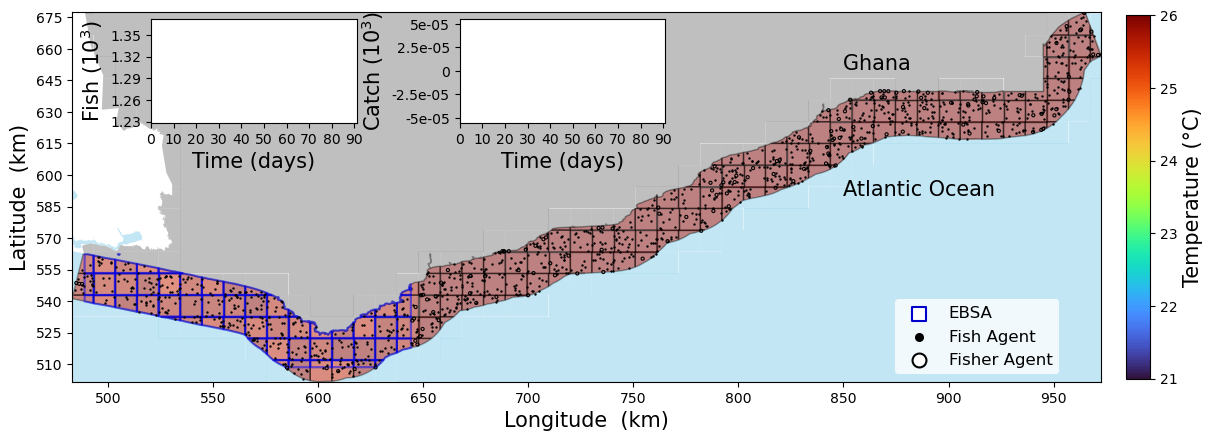

In [12]:
def Observe():
    ### invoking spatial characters for plotting
    eez_12nm_ivorycoast  = gpd.read_file(os.path.join(os.getcwd(), 'eez_12nm_ivorycoast/eez_12nm.shp')) # Exclusive Economic Zone (200 nautical miles)
    eez_12nm_ivorycoast= eez_12nm_ivorycoast.to_crs(epsg=32630) # reproject crs

    #Ghana map
    place_name = 'Ghana'
    boundaries  = ox.geocode_to_gdf(place_name)
    boundaries = boundaries.to_crs(IFA.crs)
    #Ivory coast map
    place_name1 = 'Ivory coast'
    boundaries1  = ox.geocode_to_gdf(place_name1)
    boundaries1 = boundaries1.to_crs(IFA.crs)
    #land
    upper_land = gpd.overlay(cell, boundaries, how='intersection') # upper part of land based on map
    upper_land1 = gpd.overlay(cells_eez_12nm, upper_land, how='symmetric_difference') # upper part of land not including eez_12nm  
    #ocean
    # lower_sea = gpd.overlay(cells_eez_24nm, upper_land, how='union',keep_geom_type=True) # lower sea of Ghana
    lower_sea = gpd.overlay(cells_eez_12nm, upper_land, how='union',keep_geom_type=True) # lower sea of Ghana
    lower_sea1 = gpd.overlay(cell, lower_sea, how='symmetric_difference')
    
    left_side = gpd.overlay(boundaries1, lower_sea1, how='intersection') # side ivory coast 
    left_side1 = gpd.overlay(lower_sea1, left_side, how='symmetric_difference') # atlantic ocean 
    left_side3 = gpd.overlay(eez_12nm_ivorycoast, left_side , how='intersection')

    ### Plotting
    fig, ax = plt.subplots(figsize=(16,8))
    minx1, miny1, maxx1, maxy1 = IFA['geometry'].total_bounds# IFA bounds
     
    # create a legend: we'll plot empty lists with the desired color, label, symbol
    for facecol, label, edgecol, symb, alph in [
                                              # ('white','Spawning hotspots','red','s', 1),
                                              ('white','EBSA','mediumblue','s', 1),
                                              # ('white','Non-EBSA','black','s', 1), 
                                              # ('red','Closed to Fishing ','red','s', 0.3),
                                              ('black','Fish Agent','black','.', 1) ,
                                              ('white','Fisher Agent','black','o', 1) 
                                              ]:
        ax.scatter([], [], facecolor=facecol, s=100, label=label, alpha=alph, edgecolors=edgecol, marker=symb,linewidths=1.5 )
        ax.legend(facecolor="white", edgecolor="none", prop={"size":12}, loc=(0.8,0.02),ncol=1 ) #loc=(0.7,0.02)
   
    # cells.plot(ax=ax,facecolor="none", edgecolor='black', lw=1, zorder=1, alpha=0.5)
    vmin = 21 #cells['temperature'].min()  
    vmax = 26 #cells['temperature'].max()  
    tick_values = np.linspace(vmin, vmax, num=6)
    cells.plot(ax=ax, column='temperature', cmap='turbo', legend=True, edgecolor='black', lw=1, alpha=0.5, vmin=vmin, vmax=vmax,
               legend_kwds={'shrink': 0.59, 'aspect': 15, 'orientation': 'vertical', 'label': 'Temperature (°C)', 'ticks': tick_values, 'pad': 0.02 })    
    cax = fig.axes[-1]
    cax.set_ylabel('Temperature (°C)',fontsize=15)  # colorbar title size
    
    upwelling_gdf_bound.plot(ax=ax,facecolor="none", edgecolor='blue', lw=1.6, zorder=2, alpha=0.5)

    fish_geodata.plot(ax=ax,color='black', edgecolor='black' ,marker = '.', markersize=2, zorder=2)

    if simulation_type in ['NO CLOSURE', 'CENTRAL UPWELLING CLOSURE']:
        pirogue_geodata.plot(ax=ax,facecolor='none', edgecolor='black' ,marker = 'o', linewidth =0.8,markersize=5,zorder=2)
    
    # if simulation_type == 'TOTAL CLOSURE' and closure_month != month and month in ['July', 'August', 'September']:
    if simulation_type == 'TOTAL CLOSURE' and month not in closure_month and month in ['July', 'August', 'September']:
        pirogue_geodata.plot(ax=ax,facecolor='none', edgecolor='black' ,marker = 'o', linewidth =0.8,markersize=5,zorder=2)
  
    
    upper_land1.plot(ax=ax,facecolor='grey', edgecolor='none', lw=1,zorder=1,alpha=0.5)
    left_side1.plot(ax=ax,facecolor='skyblue', edgecolor='none', lw=1,zorder=1,alpha=0.5)
    left_side3.plot(ax=ax,facecolor='skyblue', edgecolor='none', lw=1,zorder=1,alpha=0.5)    
    
    ax.set_xlabel('Longitude  (km)',fontsize=15)
    ax.set_ylabel('Latitude  (km)',fontsize=15)

 
    ax.text(850 *1000, 650 * 1000, 'Ghana ',fontsize=15)
    # ax.text(850 *1000, 550 * 1000, 'Atlantic Ocean ',fontsize=16)
    ax.text(850 *1000, 590 * 1000, 'Atlantic Ocean ',fontsize=15)
    
    # set axis limit as boundaries of Ghana
    ax.set_xlim(([minx1, maxx1]))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10, integer=True, prune=None))
    ax.set_ylim(([miny1, maxy1])) 
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12, integer=True, prune=None))
    #ax.xaxis.set_major_locator(LinearLocator(numticks=7))
    #ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    
  #   # generate evenly spaced ticks including endpoints
  #   xticks = np.linspace(minx1,maxx1, num=6)  # 6 ticks from 0 to 10
  #   yticks = np.linspace(miny1,maxy1, num=6)  # 7 ticks from 20 to
  #   # set custom ticks
  #   ax.set_xticks(xticks)
  #   ax.set_yticks(yticks)
  # # # ax.set_yticks([]) ; ax.set_xticks([]) 
  #   # ax.set_axis_off()

    
    # make axis number label not scientific notation
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
           
    # # change axis from meters to kilometers
    m2km = lambda x, _: f'{x/1000:g}'
    ax.xaxis.set_major_formatter(m2km)
    ax.yaxis.set_major_formatter(m2km)
    
    # make insert figure within the main plot
    axins = inset_axes(ax,width='40%', height='40%', bbox_to_anchor=(0.07, 0.3, 0.5, 0.7), bbox_transform=ax.transAxes, loc='upper left') # tuple is (x0, y0, width, height)
    axins1 = inset_axes(ax,width='40%', height='40%', bbox_to_anchor=(0.37, 0.3, 0.5, 0.7), bbox_transform=ax.transAxes, loc='upper left') 
    #axins2 = inset_axes(ax,width='40%', height='40%', bbox_to_anchor=(0.49, 0.12, 0.5, 0.7), bbox_transform=ax.transAxes, loc='lower right') 
    axins.plot(time1,TOTAL_FISH, color='black',linewidth=2)
    axins1.plot(time1,CURRENT_CATCH, color='black',linewidth=2)
    #axins2.bar(time1, AVERAGE_EFFORT, color='white', edgecolor='black', width=0.8)
    axins.set_xlabel('Time (days)',fontsize=15)
    axins.set_ylabel('Fish ($10^3$)',fontsize=15,color='black')
    axins1.set_xlabel('Time (days)',fontsize=15,color='black')
    axins1.set_ylabel('Catch ($10^3$)',fontsize=15,color='black')
    #axins2.set_xlabel('Time (days)',fontsize=12,color='black')
    #axins2.set_ylabel('Avg. Effort',fontsize=12,color='black')
    
    inset_axis = lambda x, _: f'{x/1000:g}' # setting in 10^3
    axins.yaxis.set_major_formatter(inset_axis)
    axins1.yaxis.set_major_formatter(inset_axis)

    # axins.set_ylim(([0, K]))
    #axins.yaxis.set_major_locator(LinearLocator(numticks=5))
    axins.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True, prune=None))
    axins.set_xlim(([0, num_days]))
    axins.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10, integer=True, prune=None))

    # axins1.set_ylim(([0, K/3]))
    axins1.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True, prune=None))
    axins1.set_xlim(([0, num_days]))
    axins1.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10, integer=True, prune=None))
     
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85) 
    plt.savefig('day_%04d.png' %time, bbox_inches='tight', pad_inches=0.1, dpi=1000) 


# plt.clf
Observe()
# plt.show() 


## reset geometry of pirogues during to closure_month

In [13]:
def reset_geometry():
    while True: 
        cell_pirogue_index=random.choice(cells_pirogue_movement_all.index.tolist()) # random index
        cell_pirogue=cells_pirogue_movement_all.at[cell_pirogue_index,'geometry']  # geometry of cell to contain pirogues
        xmin, ymin, xmax, ymax = cell_pirogue.bounds # get the bounds of the cell to contain pirogue
        pirogue_x = random.uniform(xmin, xmax)
        pirogue_y = random.uniform(ymin, ymax)
        pnt = Point(pirogue_x,pirogue_y)
        if cell_pirogue.contains(pnt):
            return pnt   
            

### updating fish and pirogues asyncronously

In [14]:
def update_one_time():
    global time, time1, month, closure_month, cells_pirogue_movement_all
    time += 1  # update time
    
    # update fish
    if len(fish_geodata) > 0:
        t = 0.
        while t < 1 :
            t += 1. / len(fish_geodata) 
            Fish_Update()
    
    # update pirogues
    if simulation_type in ['NO CLOSURE', 'CENTRAL UPWELLING CLOSURE']:
        t = 0.
        while t < 1 :
            t += 1. / len(pirogue_geodata) 
            # t += 1. / (len(pirogue_geodata)/3) # takes 3 days for all to update (meaning on average pirogues updates once every three days)
            Pirogue_Update() 
    elif simulation_type == 'TOTAL CLOSURE' and month not in closure_month and month in ['July', 'August', 'September']:
        t = 0.
        while t < 1 :
            t += 1. / len(pirogue_geodata) 
            # t += 1. / (len(pirogue_geodata)/3) # takes 3 days for all to update (meaning on average pirogues updates once every three days)
            Pirogue_Update()


    # assign temperatures based on zones (hotspot, central upwelling, none)
    cells['temperature'] = cells.apply(lambda row: (scaled_upwelling_temp[time]-random.uniform(0,0.5)) if any(row['geometry'].within(row1) or row['geometry'].intersects(row1) or row['geometry'].touches(row1) for row1 in upwelling_gdf_bound['geometry']) # hotspots temp
                                       else (scaled_upwelling_temp[time]+random.uniform(0,0.5)), 
                                       axis=1)
    # set month by time
    month = 'July' if time <= 30 else  'August' if (30 < time <= 60) else 'September'


    ## CENTRAL UPWELLING CLOSURE by month
    if simulation_type == 'CENTRAL UPWELLING CLOSURE' and month in closure_month and month in ['July', 'August', 'September']:
        if time % 30 == 1:
            cells_pirogue_movement_all = gpd.overlay(cells, upwelling_gdf_bound, how='difference')
            pirogue_geodata['geometry'] = pirogue_geodata.apply(lambda row: reset_geometry(), axis=1)
    elif simulation_type == 'CENTRAL UPWELLING CLOSURE' and month not in closure_month and month in ['July', 'August', 'September']:
        if time % 30 == 1:
            cells_pirogue_movement_all = cells
            pirogue_geodata['geometry'] = pirogue_geodata.apply(lambda row: reset_geometry(), axis=1)

       
    # housekeeping the data
    time1.append(time) # update time
    TOTAL_FISH.append(len(fish_geodata)) # update total fishes
    TOTAL_CATCH.append(pirogue_geodata['catch'].sum()) # update total catch
    CURRENT_CATCH.append(pirogue_geodata['current catch'].sum()) # update total current catch
    
    # if simulation_type == 'TOTAL CLOSURE' and month in closure_month and month in ['July', 'August', 'September']:
    #    pirogue_geodata['effort'] = float(0)
    AVERAGE_EFFORT.append(pirogue_geodata['effort'].mean()) # update average effort
    # pirogue_geodata['currentcatch_time%d'% (time)] = pirogue_geodata.apply(lambda row: row['current catch'] , axis =1) # keep current catch at each time step
    # pirogue_geodata['effort_time%d'% (time)] = pirogue_geodata.apply(lambda row: row['effort'] , axis =1) # keep current effort at each time step
    pirogue_geodata[f'currentcatch_time{time}'] = pirogue_geodata['current catch']
    pirogue_geodata[f'effort_time{time}'] = pirogue_geodata['effort']
    pirogue_geodata.to_csv("final_pirogue_geodata.csv", header=True) # convert pirogue geodata to csv (containing currents catches per time) 
    pirogue_geodata['current catch'] = pirogue_geodata.apply(lambda row: 0, axis =1) # reset current catch to zero
   
    csvfile = "updated_simulation_data.csv"   # a csv-file output 
    header = ['time','number_fish','total_catch','current catch', 'average_effort']
    main_data = [time1, TOTAL_FISH, TOTAL_CATCH, CURRENT_CATCH, AVERAGE_EFFORT]
    with open(csvfile, "w") as output:
        writer = csv.writer(output) 
        writer.writerow(header)
        writer.writerows(zip(*main_data))  

# update_one_time() 


### simulate over a number of time steps

In [ ]:
Param_Initialize() # read files and initialise all parameters
Regular_Cell() # set IFA into regular cells
Hotspots_upwelling() # set the hotspots and upwelling
Fish_Initialize() # initialise clusters of fish
Pirogue_Initialize() # initialize the pirogues
Observe() # plot to observe

for j in range(1, num_days):  # num_days
    update_one_time()
    Observe()
    
# os.system("ffmpeg -v quiet -r 5 -i day_%04d.png -vcodec mpeg4  -y -s:v 1920x1080 updated_simulation_movie.mp4") # convert png files to a movie
